# Student Feedback & Analysis System - Walkthrough
Run cells top to bottom. Run `python src/run_pipeline.py` once before this notebook.

## 1. Load data (T2)

In [1]:
import sys; sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/feedback_clean.csv')
print(df.shape)
df.head()

(450, 10)


,student_id,teacher,subject,rating,comment,date,clean_comment,sentiment,topic,predicted_sentiment
0,S1223,Prof. Mishra,Artificial Intelligence,1,"Padhane ka tarika bekaar hai, speed bahut fast...",2026-01-05,padhane tarika bekaar speed bahut fast,negative,Teaching,negative
1,S1080,Dr. Verma,Data Structures,5,"Mam bahut acche se explain karti hain, doubts ...",2026-01-05,mam bahut acche explain doubt clear highly rec...,positive,Teaching,positive
2,S1055,Prof. Gupta,Database Systems,3,"Exam was moderate, some questions were tricky....",2026-01-05,exam moderate question tricky chal,neutral,Exams/Evaluation,neutral
3,S1112,Prof. Sharma,Artificial Intelligence,4,"Very helpful faculty, explains difficult topic...",2026-01-06,very helpful faculty explain difficult topic s...,positive,Teaching,positive
4,S1028,Dr. Singh,Operating Systems,4,Mam hamesha time pe aati hain aur students ki ...,2026-01-06,mam hamesha time aati student help,positive,Behaviour/Support,positive


In [2]:
df.info(); print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   student_id           450 non-null    str  
 1   teacher              450 non-null    str  
 2   subject              450 non-null    str  
 3   rating               450 non-null    int64
 4   comment              450 non-null    str  
 5   date                 450 non-null    str  
 6   clean_comment        450 non-null    str  
 7   sentiment            450 non-null    str  
 8   topic                450 non-null    str  
 9   predicted_sentiment  450 non-null    str  
dtypes: int64(1), str(9)
memory usage: 120.9 KB
student_id             0
teacher                0
subject                0
rating                 0
comment                0
date                   0
clean_comment          0
sentiment              0
topic                  0
predicted_sentiment    0
dtype: int64


## 2. Preprocessing (T3)

In [3]:
from preprocess import clean_text
for c in df.comment.head(3):
    print(c, '\n  ->', clean_text(c))

Padhane ka tarika bekaar hai, speed bahut fast hai. 
  -> padhane tarika bekaar speed bahut fast
Mam bahut acche se explain karti hain, doubts clear ho jaate hain. Highly recommended! 
  -> mam bahut acche explain doubt clear highly recommend
Exam was moderate, some questions were tricky. Chal jata hai. 
  -> exam moderate question tricky chal


## 3. Sentiment prediction (T4)

In [4]:
from predict import predict_comment
predict_comment('Sir bahut accha padhate hain, samajh aa jata hai')

{'sentiment': 'positive',
 'confidence': 0.768,
 'probabilities': {'negative': 0.196, 'neutral': 0.036, 'positive': 0.768},
 'topic': 'Teaching',
 'cleaned': 'sir bahut accha padhate samajh aa'}

In [5]:
pd.read_csv('../outputs/model_comparison.csv', index_col=0)

,accuracy,f1_macro,cv_accuracy
Naive Bayes,0.8667,0.8241,0.88
Logistic Regression,0.8778,0.8353,0.86
VADER (baseline),0.6556,0.5278,NaN


## 4. Topics (T5)

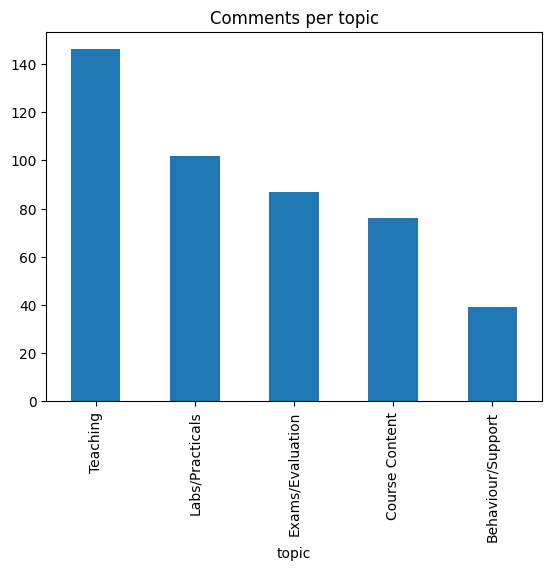

In [6]:
df.topic.value_counts().plot(kind='bar'); plt.title('Comments per topic'); plt.show()

## 5. Analysis (T6)

In [7]:
import analysis as A
A.teacher_report(df)

sentiment,positive,neutral,negative,avg_rating,responses
teacher,,,,,
Prof. Sharma,77.7,10.6,11.7,3.86,94
Dr. Singh,57.8,16.7,25.6,3.42,90
Dr. Verma,61.1,7.8,31.1,3.33,90
Prof. Mishra,25.8,12.4,61.8,2.42,89
Prof. Gupta,18.4,24.1,57.5,2.33,87


In [8]:
A.subject_report(df)

sentiment,positive,neutral,negative,avg_rating,responses
subject,,,,,
Operating Systems,57.8,16.7,25.6,3.42,90
Data Structures,61.1,7.8,31.1,3.33,90
Artificial Intelligence,52.5,11.5,36.1,3.16,183
Database Systems,18.4,24.1,57.5,2.33,87


In [9]:
A.topic_complaints(df)

sentiment,positive,neutral,negative,avg_rating,responses
topic,,,,,
Behaviour/Support,41.0,15.4,43.6,2.79,39
Labs/Practicals,50.0,10.8,39.2,3.09,102
Teaching,49.3,13.0,37.7,3.10,146
Course Content,56.6,9.2,34.2,3.25,76
Exams/Evaluation,42.5,24.1,33.3,3.06,87


In [10]:
A.top_issues(df)

,complaint,count
0,Teache,18
1,Syllabu,16
2,La,14
3,Practica,12
4,Si,12


In [11]:
for t in sorted(df.teacher.unique()):
    print(A.teacher_summary_text(df, t))

Dr. Singh (Operating Systems): Good. 58% positive, 26% negative from 90 responses (avg rating 3.42/5). Strongest area: Exams/Evaluation. Weakest area: Behaviour/Support (57% negative).
Dr. Verma (Data Structures): Good. 61% positive, 31% negative from 90 responses (avg rating 3.33/5). Strongest area: Teaching. Weakest area: Exams/Evaluation (54% negative).
Prof. Gupta (Database Systems): Needs urgent improvement. 18% positive, 57% negative from 87 responses (avg rating 2.33/5). Strongest area: Labs/Practicals. Weakest area: Course Content (67% negative).
Prof. Mishra (Artificial Intelligence): Needs urgent improvement. 26% positive, 62% negative from 89 responses (avg rating 2.42/5). Strongest area: Course Content. Weakest area: Behaviour/Support (83% negative).
Prof. Sharma (Artificial Intelligence): Excellent. 78% positive, 12% negative from 94 responses (avg rating 3.86/5). Strongest area: Course Content. Weakest area: Labs/Practicals (20% negative).


## 6. Charts (T7)

In [12]:
import visualize as V
V.sentiment_pie(df); V.teacher_bar(df); V.heatmap_fig(df); V.trend_fig(df); plt.show()